# Getting Started with FeatureForge

End-to-end walkthrough on the **Banknote Authentication** dataset — no API key required for most sections.

**Contents:**
1. Configuration & Settings
2. Load Banknote Data
3. Baseline Evaluation
4. Sandbox: Safe Code Execution
5. FeatureForge Demo (LLM required)


## 1. Setup

In [1]:
import os
import pathlib
import sys
import warnings

warnings.filterwarnings('ignore')
os.environ.setdefault('FF_LOG_LEVEL', 'warning')

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(pathlib.Path('.').resolve()))
from _utils import get_llm_client, load_banknote


In [2]:
from feature_forge.config import LLMConfig, RouterConfig, Settings

settings = Settings()
print(f'Task: {settings.task}, Metric: {settings.metric}, Rounds: {settings.n_rounds}')
print(f'LLM model: {settings.llm.model}, Router: {settings.router.strategy}')
print(f'CV folds: {settings.evaluation.cv_folds}')


Task: classification, Metric: auc, Rounds: 4
LLM model: deepseek-chat, Router: hybrid
CV folds: 5


In [3]:
# Constructor overrides
custom = Settings(task='classification', metric='auc', n_rounds=3,
                  llm=LLMConfig(temperature=0.3),
                  router=RouterConfig(strategy='hybrid'))
print(f'Task: {custom.task}, Rounds: {custom.n_rounds}, Router: {custom.router.strategy}')


Task: classification, Rounds: 3, Router: hybrid


In [4]:
# Validation catches bad values
try:
    Settings(llm=LLMConfig(temperature=3.0))
except Exception as e:
    print(f'Caught: {e}')


Caught: 1 validation error for LLMConfig
temperature
  Value error, temperature must be in [0, 2], got 3.0 [type=value_error, input_value=3.0, input_type=float]
    For further information visit https://errors.pydantic.dev/2.12/v/value_error


## 3. Banknote Authentication Dataset

We use the Banknote Authentication dataset from UCI with 4 numeric features
extracted from wavelet-transformed banknote images: `variance`, `skewness`, `curtosis`, `entropy`.
Target: whether the note is forged (1) or genuine (0).


In [5]:
X_train, X_test, y_train, y_test = load_banknote()
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Columns: {list(X_train.columns)}')
print(f'Forged distribution (train): {y_train.value_counts().to_dict()}')
X_train.head(5)


Train: (960, 4), Test: (412, 4)
Columns: ['variance', 'skewness', 'curtosis', 'entropy']
Forged distribution (train): {1: 533, 0: 427}


,variance,skewness,curtosis,entropy
296,0.051979,7.05210,-2.054100,-3.15080
614,2.508900,6.84100,-0.029423,0.44912
771,-0.985400,-6.66100,5.824500,0.54610
1009,-3.571300,-12.49220,14.888100,-0.47027
192,1.457800,-0.08485,4.178500,0.59136


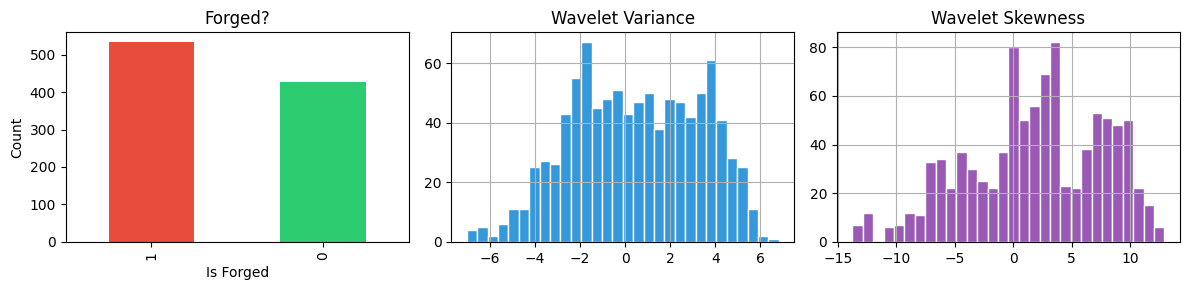

In [6]:
# Quick EDA
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

y_train.value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Forged?'); axes[0].set_xlabel('Is Forged'); axes[0].set_ylabel('Count')

X_train['variance'].hist(ax=axes[1], bins=30, color='#3498db', edgecolor='white')
axes[1].set_title('Wavelet Variance')

X_train['skewness'].hist(ax=axes[2], bins=30, color='#9b59b6', edgecolor='white')
axes[2].set_title('Wavelet Skewness')

plt.tight_layout(); plt.show()


## 4. Baseline Evaluation

Before feature engineering, let's establish a baseline using the original features.


In [7]:
from feature_forge.evaluation import CVEvaluator, ModelFactory
from feature_forge.evaluation.metrics import get_metric

config = Settings(task='classification', metric='auc')
evaluator = CVEvaluator(config=config)
baseline_auc = evaluator.evaluate_baseline(X_train, y_train)
print(f'Baseline AUC (original features): {baseline_auc:.4f}')


Baseline AUC (original features): 0.9992


In [8]:
# Test handcrafted features
handcrafted = pd.DataFrame({
    'variance_skew_ratio': X_train['variance'] / (X_train['skewness'].abs() + 1e-8),
    'curtosis_entropy_ratio': X_train['curtosis'] / (X_train['entropy'].abs() + 1e-8),
    'variance_squared': X_train['variance'] ** 2,
    'total_wavelet_energy': X_train['variance'] + X_train['skewness'] ** 2 + X_train['curtosis'] ** 2 + X_train['entropy'] ** 2,
})
gain = evaluator.evaluate_feature(X_train, y_train, handcrafted, baseline_score=baseline_auc)
print(f'CV gain from handcrafted features: {gain:+.4f}')


CV gain from handcrafted features: +0.0001


In [9]:
# Available models and metrics
factory = ModelFactory()
for name in ['xgboost', 'random_forest']:
    print(f'{name}: {type(factory.get_model(name, task="classification")).__name__}')
print()
for m in ['auc', 'acc', 'f1', 'rmse', 'r2']:
    print(f'{m}: {get_metric(m).__name__}')


xgboost: XGBClassifier
random_forest: RandomForestClassifier

auc: auc_score
acc: acc_score
f1: f1_score_metric
rmse: rmse_score
r2: r2_score_metric


## 5. Sandboxed Code Execution

LLM-generated code runs in an **AST-validated, process-isolated sandbox**.


In [10]:
from feature_forge.evaluation.sandbox import SandboxedExecutor

sandbox = SandboxedExecutor(timeout_seconds=5.0, max_memory_mb=256)

# Safe code: generate banknote features
safe_code = """\nimport pandas as pd
import numpy as np

def generate_features(df):
    result = pd.DataFrame(index=df.index)
    result['skewness_squared'] = df['skewness'] ** 2
    result['variance_log'] = np.log1p(df['variance'].abs())
    result['entropy_exp'] = np.exp(-df['entropy'])
    return result
"""
features = sandbox.execute(safe_code, X_train)
print(f'Generated: {list(features.columns)}, Shape: {features.shape}')
features.head(3)


Generated: ['skewness_squared', 'variance_log', 'entropy_exp'], Shape: (960, 3)


,skewness_squared,variance_log,entropy_exp
296,49.732114,0.050673,23.354741
614,46.799281,1.255303,0.638190
771,44.368921,0.685820,0.579204


In [11]:
# Sandbox blocks dangerous code
dangerous = """\nimport os
def generate_features(df):
    os.system('rm -rf /')
    return df
"""
try:
    sandbox.execute(dangerous, X_train)
except Exception as e:
    print(f'Blocked: {type(e).__name__}: {e}')


{"reason": "import_not_allowed: os", "event": "sandbox_validation_blocked", "level": "warning", "timestamp": "2026-05-15T06:19:44.469561Z", "span": null}


Blocked: SandboxValidationError: Import not allowed: os


## 6. FeatureForge Demo

The main API — an sklearn-compatible transformer:
```python
fe = FeatureForge(mode='full')
fe.fit(X_train, y_train)        # multi-agent pipeline
X_enhanced = fe.transform(X_test)  # apply generated features
```

> ⚠️ **Requires `DEEPSEEK_API_KEY`.** Pipeline errors are caught gracefully.


In [12]:
from feature_forge.api import FeatureForge

llm = get_llm_client()
fe = None

if llm is None:
    print('⚠️  No LLM API key. Set DEEPSEEK_API_KEY to run this cell.')
else:
    try:
        fe = FeatureForge(
            config=Settings(n_rounds=2, metric='auc'),
            llm_client=llm,
            mode='full',
        )
        fe.fit(X_train, y_train)
        print(f'Selected features: {fe.selected_features}')
        X_test_enhanced = fe.transform(X_test)
        print(f'Test: {X_test.shape} -> {X_test_enhanced.shape}')

        # Compare with baseline
        from xgboost import XGBClassifier
        clf = XGBClassifier(n_estimators=100, max_depth=4, random_state=42, eval_metric='logloss')
        clf.fit(X_train, y_train)
        baseline_acc = clf.score(X_test, y_test)
        clf.fit(X_test_enhanced, y_test)
        enhanced_acc = clf.score(X_test_enhanced, y_test)
        print(f'Baseline accuracy: {baseline_acc:.4f}')
        print(f'Enhanced accuracy: {enhanced_acc:.4f}')
    except Exception as e:
        print(f'Pipeline error: {type(e).__name__}: {e}')


⚠️  No LLM API key found. Set DEEPSEEK_API_KEY or OPENAI_API_KEY to run LLM-dependent cells.
⚠️  No LLM API key. Set DEEPSEEK_API_KEY to run this cell.


In [13]:
# Inspect generated code (if pipeline ran)
if fe is not None and hasattr(fe, 'feature_codes') and fe.feature_codes:
    for i, code in enumerate(fe.feature_codes[:2]):
        print(f'--- Code block {i} ---')
        print(code[:500])
        print()
else:
    print('No generated code to inspect.')


No generated code to inspect.


## 7. ExperimentalPlatform (One-Liner API)

The `ExperimentalPlatform` facade wraps dataset loading, baseline construction,
cross-validation, and result reporting into a single object.


In [14]:
from feature_forge import ExperimentalPlatform

platform = ExperimentalPlatform()
print(f'Datasets:  {platform.list_datasets()}')
print(f'Methods: {platform.list_methods()}')
print(f'Models:    {platform.list_models()}')
print(f'Metrics:   {platform.list_metrics()}')


Datasets:  ['house_prices', 'titanic']
Methods: ['caafe', 'llmfe', 'malmas', 'malmus', 'openfe']
Models:    ['catboost', 'lightgbm', 'mlp', 'random_forest', 'xgboost']
Metrics:   ['acc', 'auc', 'f1', 'mae', 'nrmse', 'r2', 'rmse']


In [15]:
if llm is None:
    print('Skipping platform run — no API key.')
else:
    try:
        results = platform.run(
            datasets=['titanic'],
            methods=['malmus'],
            models=['xgboost'],
            seeds=[42],
        )
        print(platform.report(results))
    except Exception as e:
        if 'kaggle' in str(e).lower():
            print('⚠️  Kaggle package required for ExperimentalPlatform datasets.')
            print('   Install with: uv sync --extra kaggle')
        else:
            print(f'Platform run error: {type(e).__name__}: {e}')


Skipping platform run — no API key.


In [16]:
from feature_forge.methods import MethodRegistry

methods = MethodRegistry.get_builtin_methods()
print(f'{len(methods)} registered methods:')
for name, cls in methods.items():
    print(f'  {name}: {cls.__name__}')

5 registered methods:
  malmas: MALMASMethod
  openfe: OpenFEMethod
  caafe: CAAFEMethod
  llmfe: LLMFEMethod
  malmus: MalmusMethod


In [17]:
from feature_forge.methods.malmas.prompts import get_registry

registry = get_registry()
prompt = registry.get("code_generation")
print(f'System prompt ({len(prompt.system)} chars):')
print(prompt.system[:300] + '...\n')
print(f'Description: {prompt.description}')

System prompt (3880 chars):
You are CodeGenerationAgent, a feature engineering agent that specializes in generating pandas or numpy code snippets based on user-specified feature derivation logic for structured data.

🎯 Your goal:
To generate robust and reusable feature engineering code that prepares data for preprocessing and ...

Description: Generate Python code from feature specs


## Summary

| Concept | Key API |
|---------|---------|
| Settings | `Settings()`, `LLMConfig`, `RouterConfig` |
| Data | `load_banknote()`, real-world preprocessing |
| CVEvaluator | `evaluate_baseline()`, `evaluate_feature()` |
| Sandbox | `SandboxedExecutor.execute()` |
| FeatureForge | `fit()`, `transform()`, `selected_features` |
| ExperimentalPlatform | `run()`, `report()`, `list_methods()` |

- Methods are discovered via `MethodRegistry` and can be extended through entry points
- Prompts are loaded from YAML files via `PromptRegistry`

Next: **[02_pipeline_deep_dive.ipynb](./02_pipeline_deep_dive.ipynb)**
